*Workflow*
Load train images -> Normalize -> Augment -> Train
Load test images -> Normalize -> Evaluate

In [1]:
from PIL import Image
import numpy as np
import os
import tensorflow as tf
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import gc



gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)




2026-02-18 20:00:52.465661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771441252.650278   79425 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771441252.714259   79425 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771441252.909398   79425 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771441252.909635   79425 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771441252.909640   79425 computation_placer.cc:177] computation placer alr

In [2]:
def load_images(folder):
    images = []
    labels = []
    
    class_names = sorted(os.listdir(folder))
    
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)
        
        if not os.path.isdir(class_path):
            continue
        
        for file in os.listdir(class_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                path = os.path.join(class_path, file)
                
                img = Image.open(path)
                img = np.array(img, dtype=np.float32)
                
                images.append(img)
                labels.append(label)
    
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

In [3]:
def augment_image(img):
    # Horizontal flip
    if random.random() > 0.5:
        img = np.fliplr(img)
    
    # Vertical flip
    if random.random() > 0.5:
        img = np.flipud(img)
    
    # Random rotation (90° steps for simplicity)
    k = random.randint(0, 3)
    img = np.rot90(img, k)
    
    return img

def augment_data(X_train, y_train):
    # Extract Normal Ovaries (NO) class
    X_NO = X_train[y_train == 1]
    y_NO = y_train[y_train == 1]

    # Extract Ovarian Cancer (OC) class
    X_OC = X_train[y_train == 2]
    y_OC = y_train[y_train == 2]

    # Apply augmentation to training images
    X_NO_aug_1 = np.array([augment_image(img) for img in X_NO])
    X_NO_aug_2 = np.array([augment_image(img) for img in X_NO])
    X_OC_aug_1 = np.array([augment_image(img) for img in X_OC])
    X_OC_aug_2 = np.array([augment_image(img) for img in X_OC])
    X_OC_aug_3 = np.array([augment_image(img) for img in X_OC])
    X_OC_aug_4 = np.array([augment_image(img) for img in X_OC])

    # Combine original and augmented data
    X_train = np.concatenate([X_train, X_NO_aug_1, X_NO_aug_2, X_OC_aug_1, X_OC_aug_2, X_OC_aug_3, X_OC_aug_4])
    y_train = np.concatenate([y_train, y_NO, y_NO, y_OC, y_OC, y_OC, y_OC])

    # Apply augmentation to OC training images again to further balance the dataset
    X_OC = X_train[y_train == 2]
    y_OC = y_train[y_train == 2]
    X_OC_aug_5= np.array([augment_image(img) for img in X_OC])
    X_OC_aug_6= np.array([augment_image(img) for img in X_OC])
    X_train = np.concatenate([X_train, X_OC_aug_5, X_OC_aug_6])
    y_train = np.concatenate([y_train, y_OC, y_OC])

    print(X_train.min(), X_train.max()) # Check normalization
    unique, counts = np.unique(y_train, return_counts=True)
    print(dict(zip(unique, counts))) # Check class distribution after augmentation
    
    return X_train, y_train


In [4]:
def compute_class_weights(y_train):
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(class_weights))
    print(class_weights)
    
    return class_weights

In [5]:
def build_and_train_model(X_train, y_train, X_test, y_test, class_weights):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(224,224,1)),

        tf.keras.layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Conv2D(64, (5,5), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Conv2D(128, (3,3), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Flatten(), 
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax')  # Multi-Class classification (4 classes)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=25,
        batch_size=16,
        class_weight=class_weights,
        verbose=1
    )

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.legend(['Train', 'Validation'])
    plt.show()

    return model, history

In [6]:
# One-Vs-Rest (OvR) Evaluation
def evaluate_model(model, X_test, y_test):
    y_probs = model.predict(X_test)
    y_pred = np.argmax(y_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
    auc = roc_auc_score(y_test_bin, y_probs, average='macro')

    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("AUC:", auc)
    print("Confusion Matrix:\n", cm)
    return acc, precision, recall, f1, auc


=========== FOLD 1 ===========
0.0 1.0
{np.int64(0): np.int64(919), np.int64(1): np.int64(639), np.int64(2): np.int64(645), np.int64(3): np.int64(700)}
{0: np.float64(0.7897170837867247), 1: np.float64(1.1357589984350547), 2: np.float64(1.1251937984496123), 3: np.float64(1.0367857142857142)}


I0000 00:00:1771441305.253290   79425 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-02-18 20:01:48.079850: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 582643712 exceeds 10% of free system memory.
2026-02-18 20:01:50.482773: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 582643712 exceeds 10% of free system memory.


Epoch 1/25


I0000 00:00:1771441313.426043   79684 service.cc:152] XLA service 0x79d34802a710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771441313.426207   79684 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-18 20:01:53.529163: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771441313.935818   79684 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-18 20:02:01.085311: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-input.3 = (f32[16,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,112,112]{3,2,1,0} %bitcast.5111, f32[64,32,5,5]{3,2,1,0} %bitcast.5048), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackprop

182/182 ━━━━━━━━━━━━━━━━━━━━ 50s 179ms/step - accuracy: 0.6483 - loss: 0.7873 - val_accuracy: 0.7569 - val_loss: 0.5132
Epoch 2/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.7568 - loss: 0.5466 - val_accuracy: 0.8316 - val_loss: 0.3627
Epoch 3/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 25s 135ms/step - accuracy: 0.8171 - loss: 0.4326 - val_accuracy: 0.8443 - val_loss: 0.3419
Epoch 4/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.8646 - loss: 0.3251 - val_accuracy: 0.8017 - val_loss: 0.4387
Epoch 5/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 27s 146ms/step - accuracy: 0.8911 - loss: 0.2687 - val_accuracy: 0.8443 - val_loss: 0.3691
Epoch 6/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 25s 135ms/step - accuracy: 0.9170 - loss: 0.2085 - val_accuracy: 0.8529 - val_loss: 0.3503
Epoch 7/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.9456 - loss: 0.1555 - val_accuracy: 0.8763 - val_loss: 0.3822
Epoch 8/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.9563 - loss: 0.1242 - val

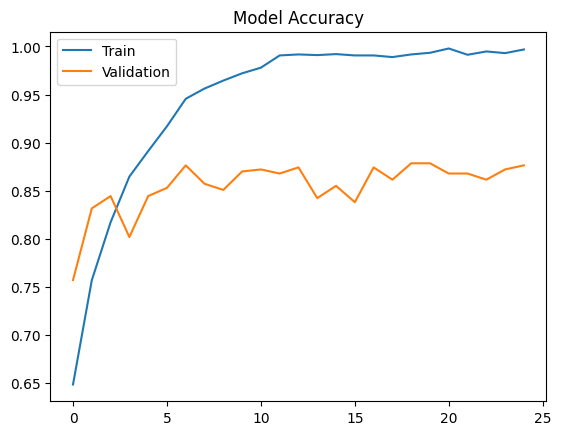

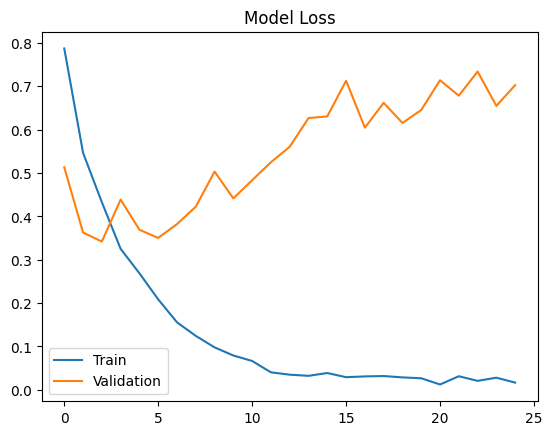

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step
Accuracy: 0.8763326226012793
Precision: 0.7031343395098625
Recall: 0.6767724867724868
F1-score: 0.6885011845930803
AUC: 0.9461780258661954
Confusion Matrix:
 [[207  18   5   0]
 [ 26  28   0   0]
 [  6   1   3   0]
 [  0   2   0 173]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

=========== FOLD 2 ===========
0.0 1.0
{np.int64(0): np.int64(919), np.int64(1): np.int64(639), np.int64(2): np.int64(645), np.int64(3): np.int64(700)}
{0: np.float64(0.7897170837867247), 1: np.float64(1.1357589984350547), 2: np.float64(1.1251937984496123), 3: np.float64(1.0367857142857142)}


2026-02-18 20:12:30.174698: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 582643712 exceeds 10% of free system memory.
2026-02-18 20:12:32.960333: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 582643712 exceeds 10% of free system memory.


Epoch 1/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 38s 183ms/step - accuracy: 0.6442 - loss: 0.7967 - val_accuracy: 0.8188 - val_loss: 0.4367
Epoch 2/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.7447 - loss: 0.5710 - val_accuracy: 0.8422 - val_loss: 0.3800
Epoch 3/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step - accuracy: 0.8164 - loss: 0.4370 - val_accuracy: 0.8358 - val_loss: 0.3623
Epoch 4/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.8632 - loss: 0.3363 - val_accuracy: 0.8124 - val_loss: 0.4423
Epoch 5/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.8894 - loss: 0.2712 - val_accuracy: 0.8209 - val_loss: 0.4268
Epoch 6/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.9135 - loss: 0.2244 - val_accuracy: 0.8742 - val_loss: 0.3455
Epoch 7/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.9366 - loss: 0.1699 - val_accuracy: 0.8742 - val_loss: 0.3737
Epoch 8/25
182/182 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9518 - loss: 0

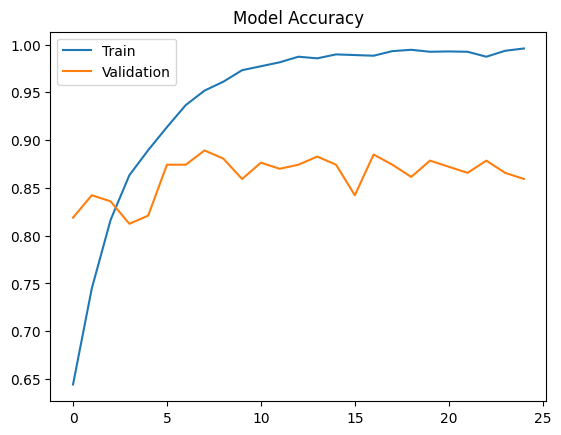

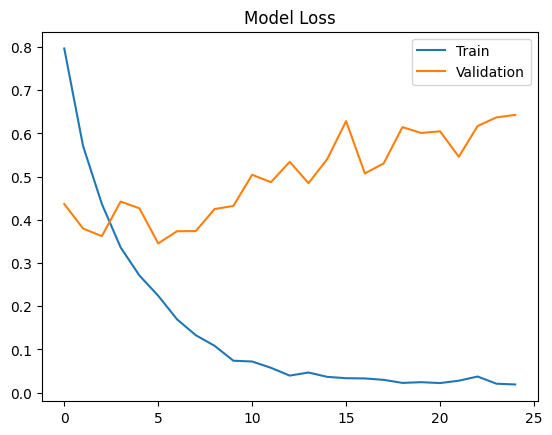

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Accuracy: 0.8592750533049041
Precision: 0.6909133085896076
Recall: 0.7067046238785369
F1-score: 0.6908014425773078
AUC: 0.9463885593564149
Confusion Matrix:
 [[189  37   4   0]
 [ 14  39   1   0]
 [  4   3   3   0]
 [  0   3   0 172]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

=========== FOLD 3 ===========
0.0 1.0
{np.int64(0): np.int64(919), np.int64(1): np.int64(642), np.int64(2): np.int64(630), np.int64(3): np.int64(700)}
{0: np.float64(0.7864526659412405), 1: np.float64(1.125778816199377), 2: np.float64(1.1472222222222221), 3: np.float64(1.0325)}


2026-02-18 20:22:51.223555: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 580235264 exceeds 10% of free system memory.


Epoch 1/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 40s 196ms/step - accuracy: 0.6399 - loss: 0.7750 - val_accuracy: 0.6588 - val_loss: 0.6342
Epoch 2/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.7665 - loss: 0.5350 - val_accuracy: 0.8507 - val_loss: 0.4149
Epoch 3/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 24s 133ms/step - accuracy: 0.8153 - loss: 0.4352 - val_accuracy: 0.8614 - val_loss: 0.3371
Epoch 4/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.8620 - loss: 0.3381 - val_accuracy: 0.8507 - val_loss: 0.3164
Epoch 5/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.8910 - loss: 0.2728 - val_accuracy: 0.8657 - val_loss: 0.3302
Epoch 6/25
 62/181 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9216 - loss: 0.2092

KeyboardInterrupt: 

In [7]:
# Loop through each fold and train/evaluate the model
all_fold_results = []
all_y_true = []
all_y_prob = []
for fold in range(1, 6):
    print(f"\n=========== FOLD {fold} ===========")
    tf.keras.backend.clear_session()
    train_dir = rf"cross_val_folds/fold_{fold}/train"
    test_dir = rf"cross_val_folds/fold_{fold}/test"

    # Load images and labels
    X_train, y_train = load_images(train_dir)
    X_test, y_test = load_images(test_dir)

    # Normalize image data
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Add channel dimension
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    # Augment training data
    X_train, y_train = augment_data(X_train, y_train)
   
    # Compute class weights
    class_weights = compute_class_weights(y_train)
   
    # Build and compile model
    model, history = build_and_train_model(X_train, y_train, X_test, y_test, class_weights)
   
    # Evaluate model
    acc, precision, recall, f1, auc = evaluate_model(model, X_test, y_test)
    all_fold_results.append([acc, precision, recall, f1, auc])
   
    # Store true labels and predicted probabilities for ROC curve analysis
    y_prob = model.predict(X_test)
    all_y_true.append(y_test)
    all_y_prob.append(y_prob)

    del X_train, y_train, X_test, y_test, model, history
    gc.collect()
    
    # Optional: reset GPU memory stats
    try:
        tf.config.experimental.reset_memory_stats('GPU:0')
    except:
        pass
   
# Print average results across folds
all_fold_results = np.array(all_fold_results)
y_true_all = np.concatenate(all_y_true)
y_prob_all = np.concatenate(all_y_prob)
print("\n===== FINAL CROSS VALIDATION RESULTS =====")
print("Mean Accuracy:", all_fold_results[:,0].mean())
print("Mean Precision:", all_fold_results[:,1].mean())
print("Mean Recall:", all_fold_results[:,2].mean())
print("Mean F1:", all_fold_results[:,3].mean())
print("Mean AUC:", all_fold_results[:,4].mean())


In [ ]:
n_classes = 4
y_true_bin = label_binarize(y_true_all, classes=[0,1,2,3])

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curve")
plt.legend()
plt.show()

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

print("AUC:", roc_auc)

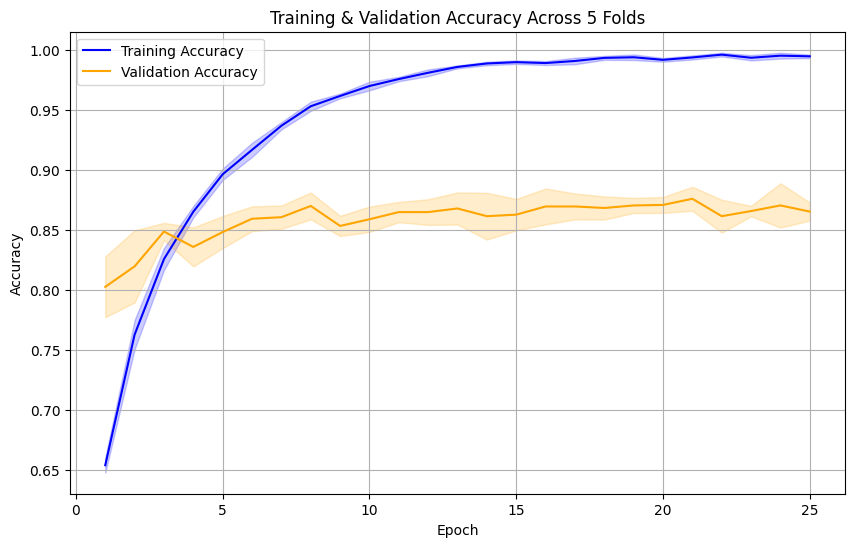

In [9]:
# Training Accuracy and Validation Accuracy Plotting
train_acc_folds = [
    [0.6573, 0.7671, 0.8257, 0.8595, 0.8887, 0.9091, 0.938, 0.9511, 0.958, 0.9645, 0.9728, 0.9817, 0.9862, 0.9859, 0.9914, 0.991, 0.9935, 0.9921, 0.9928, 0.9893, 0.9931, 0.9972, 0.99, 0.9914, 0.9928], # Fold 1
    [0.6504, 0.7461, 0.8157, 0.8626, 0.8967, 0.9215, 0.9418, 0.9487, 0.9628, 0.969, 0.9752, 0.98, 0.9859, 0.989, 0.9907, 0.9869, 0.9859, 0.9935, 0.9962, 0.9907, 0.991, 0.9948, 0.9938, 0.9952, 0.9935], # Fold 2
    [0.6458, 0.7617, 0.8364, 0.8734, 0.9035, 0.9249, 0.9343, 0.9599, 0.963, 0.9758, 0.9772, 0.9841, 0.9875, 0.9903, 0.99, 0.9907, 0.9893, 0.9955, 0.9896, 0.9941, 0.9958, 0.9969, 0.9969, 0.9983, 0.9945], # Fold 3
    [0.6641, 0.7828, 0.8354, 0.8668, 0.8948, 0.9118, 0.9332, 0.9536, 0.963, 0.9706, 0.9747, 0.9824, 0.9844, 0.9893, 0.9872, 0.9879, 0.9924, 0.9941, 0.9952, 0.9917, 0.9952, 0.9972, 0.9934, 0.9969, 0.9945], # Fold 4
    [0.6521, 0.7559, 0.815, 0.8631, 0.8976, 0.9156, 0.936, 0.9512, 0.9606, 0.9689, 0.9779, 0.9758, 0.9844, 0.9882, 0.9889, 0.9879, 0.992, 0.9907, 0.9948, 0.992, 0.9927, 0.9934, 0.9924, 0.9934, 0.9972], # Fold 5
]

val_acc_folds = [
    [0.806, 0.8422, 0.8422, 0.8614, 0.8593, 0.8721, 0.8593, 0.8699, 0.8678, 0.8721, 0.8742, 0.8678, 0.8742, 0.8721, 0.8785, 0.8763, 0.8827, 0.8806, 0.8763, 0.8763, 0.8827, 0.8806, 0.8657, 0.8806, 0.8763], # Fold 1
    [0.8038, 0.8081, 0.855, 0.8401, 0.8252, 0.8571, 0.8699, 0.855, 0.8507, 0.8401, 0.8635, 0.8721, 0.8443, 0.8806, 0.8721, 0.8849, 0.8806, 0.8742, 0.8699, 0.8742, 0.887, 0.855, 0.8635, 0.8977, 0.8529], # Fold 2
    [0.8252, 0.8443, 0.8529, 0.8145, 0.8443, 0.8571, 0.8657, 0.8614, 0.8465, 0.8635, 0.8742, 0.8443, 0.8657, 0.8699, 0.8678, 0.8827, 0.8614, 0.8721, 0.8763, 0.8763, 0.8699, 0.8699, 0.8678, 0.8678, 0.8635], # Fold 3
    [0.7548, 0.7655, 0.855, 0.8401, 0.8486, 0.8422, 0.8422, 0.887, 0.8443, 0.8614, 0.8593, 0.8742, 0.8849, 0.8593, 0.8507, 0.855, 0.8678, 0.855, 0.8699, 0.8678, 0.8593, 0.8401, 0.8721, 0.8422, 0.8657], # Fold 4
    [0.8226, 0.8376, 0.8376, 0.8226, 0.8632, 0.8675, 0.8654, 0.8761, 0.8568, 0.8568, 0.8526, 0.8654, 0.8697, 0.8248, 0.844, 0.8483, 0.8547, 0.859, 0.859, 0.859, 0.8803, 0.8611, 0.859, 0.8632, 0.8675], # Fold 5
]

# Convert to numpy arrays for easy calculation
train_acc_folds = np.array(train_acc_folds)
val_acc_folds = np.array(val_acc_folds)

# Compute mean and std per epoch
train_mean = train_acc_folds.mean(axis=0)
train_std = train_acc_folds.std(axis=0)
val_mean = val_acc_folds.mean(axis=0)
val_std = val_acc_folds.std(axis=0)

epochs = np.arange(1, 26)

# Plot with shaded std
plt.figure(figsize=(10,6))
plt.plot(epochs, train_mean, label='Training Accuracy', color='blue')
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(epochs, val_mean, label='Validation Accuracy', color='orange')
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy Across 5 Folds')
plt.legend()
plt.grid(True)
plt.show()

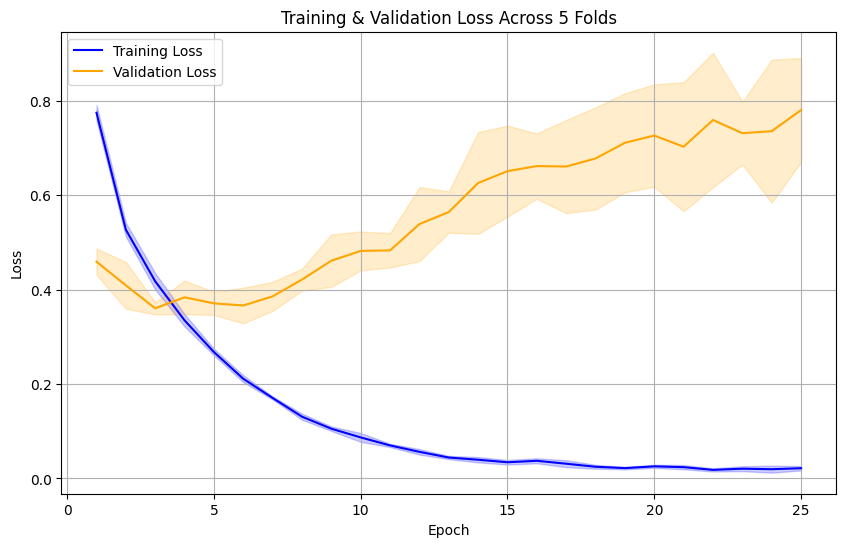

In [10]:
# Training Loss and Validation Loss Plotting
train_loss_folds = [
    [0.7787, 0.5341, 0.4309, 0.3517, 0.2775, 0.2201, 0.1754, 0.1372, 0.1123, 0.1032, 0.0757, 0.0581, 0.0465, 0.0479, 0.0326, 0.0337, 0.0282, 0.03, 0.0256, 0.0293, 0.0267, 0.0132, 0.0267, 0.0315, 0.0251], # Fold 1
    [0.7802, 0.5454, 0.4323, 0.3431, 0.27, 0.2093, 0.1692, 0.1354, 0.1026, 0.086, 0.0723, 0.0556, 0.046, 0.041, 0.0338, 0.0434, 0.0454, 0.0211, 0.0192, 0.0251, 0.0233, 0.0222, 0.0187, 0.0182, 0.0242], # Fold 2
    [0.7901, 0.5229, 0.3993, 0.3221, 0.2601, 0.1993, 0.1658, 0.1195, 0.103, 0.074, 0.0676, 0.0478, 0.0381, 0.0309, 0.0264, 0.0292, 0.0297, 0.0206, 0.0242, 0.0204, 0.0177, 0.0164, 0.0121, 0.0097, 0.0245], # Fold 3
    [0.7438, 0.502, 0.3937, 0.3172, 0.2597, 0.2097, 0.1698, 0.1282, 0.0994, 0.085, 0.0663, 0.0544, 0.043, 0.0365, 0.0409, 0.0382, 0.0246, 0.0223, 0.0196, 0.0291, 0.021, 0.0169, 0.0205, 0.0149, 0.0215], # Fold 4
    [0.782, 0.531, 0.4323, 0.3407, 0.2716, 0.2175, 0.1723, 0.1341, 0.1095, 0.0862, 0.0677, 0.0657, 0.0476, 0.0417, 0.0374, 0.0423, 0.0279, 0.0295, 0.0206, 0.0239, 0.0306, 0.0217, 0.025, 0.0233, 0.0128], # Fold 5
]

val_loss_folds = [
    [0.4375, 0.3512, 0.3695, 0.3258, 0.3709, 0.3404, 0.3678, 0.4336, 0.4583, 0.4818, 0.4965, 0.5186, 0.5493, 0.5577, 0.6377, 0.6339, 0.6152, 0.6147, 0.7044, 0.7124, 0.6767, 0.7429, 0.7249, 0.6693, 0.6874], # Fold 1
    [0.47, 0.458, 0.3472, 0.3807, 0.4014, 0.3652, 0.3604, 0.4121, 0.4238, 0.4795, 0.4329, 0.4292, 0.5411, 0.4745, 0.5107, 0.5595, 0.4973, 0.5317, 0.5505, 0.5704, 0.5479, 0.5877, 0.6271, 0.5144, 0.6941], # Fold 2
    [0.4639, 0.3881, 0.3429, 0.3862, 0.3571, 0.3672, 0.3807, 0.393, 0.4485, 0.4528, 0.4722, 0.583, 0.5439, 0.6153, 0.5918, 0.672, 0.6794, 0.722, 0.7812, 0.7375, 0.7091, 0.7592, 0.7593, 0.738, 0.8356], # Fold 3
    [0.5033, 0.477, 0.3754, 0.3889, 0.3924, 0.4351, 0.4456, 0.4599, 0.567, 0.5578, 0.5436, 0.6613, 0.6516, 0.7852, 0.7662, 0.7737, 0.7819, 0.8544, 0.8587, 0.9099, 0.9538, 1.0183, 0.8319, 0.9792, 0.973], # Fold 4
    [0.4222, 0.3717, 0.3675, 0.4374, 0.3331, 0.3247, 0.3745, 0.4084, 0.4094, 0.439, 0.471, 0.5027, 0.5367, 0.6977, 0.7496, 0.6705, 0.731, 0.6675, 0.6618, 0.703, 0.6275, 0.6901, 0.7152, 0.7785, 0.7133], # Fold 5
]

# Convert to numpy arrays for easy calculation
train_loss_folds = np.array(train_loss_folds)
val_loss_folds = np.array(val_loss_folds)

# Compute mean and std per epoch
train_mean = train_loss_folds.mean(axis=0)
train_std = train_loss_folds.std(axis=0)
val_mean = val_loss_folds.mean(axis=0)
val_std = val_loss_folds.std(axis=0)

epochs = np.arange(1, 26)

# Plot with shaded std
plt.figure(figsize=(10,6))
plt.plot(epochs, train_mean, label='Training Loss', color='blue')
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(epochs, val_mean, label='Validation Loss', color='orange')
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Across 5 Folds')
plt.legend()
plt.grid(True)
plt.show()


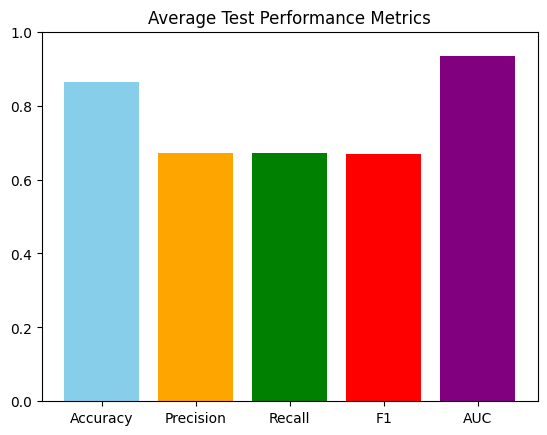

In [11]:
# Test Performance Metrics Plotting

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
values = [0.865, 0.673, 0.672, 0.668, 0.933]

plt.bar(metrics, values, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylim(0, 1)
plt.title("Average Test Performance Metrics")
plt.show()


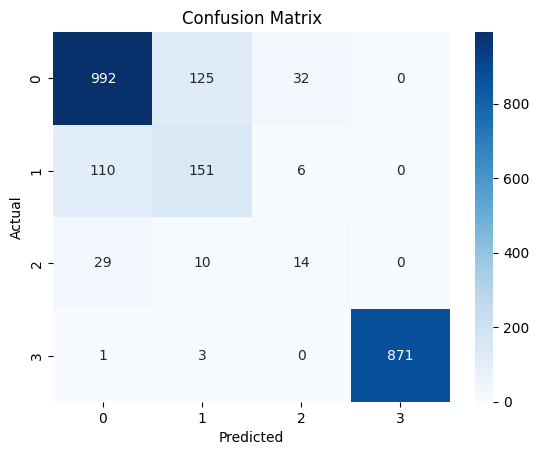

In [14]:
# Confusion Matrix Plotting
cm = np.array([[ 992, 125,  32,   0],
                [110, 151,  6,   0],
                [  29, 10,  14,   0],
                [   1,   3,   0, 871]])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


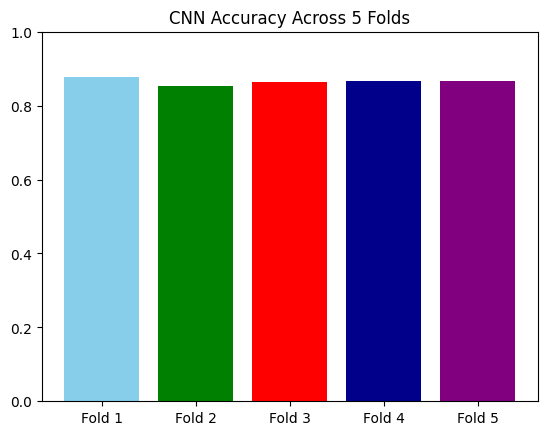

In [15]:
# Cross Validation Accuracy Plotting

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
accuracy = [0.8763, 0.8528, 0.8635, 0.8656, 0.8675]

plt.bar(folds, accuracy, color=['skyblue', 'green', 'red', 'darkblue', 'purple'])
plt.ylim(0, 1)
plt.title("CNN Accuracy Across 5 Folds")
plt.show()
